In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Train Test Split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv("sonardataset.csv", header=None)

In [3]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
1,0.02,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.018,0.0084,0.009,0.0032,R
2,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.014,0.0049,0.0052,0.0044,R
3,0.0262,0.0582,0.1099,0.1083,0.0974,0.228,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.018,0.0244,0.0316,0.0164,0.0095,0.0078,R
4,0.01,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.015,0.0085,0.0073,0.005,0.0044,0.004,0.0117,R


In [5]:
df.shape

(209, 61)

In [6]:
# rename columns
columns = []

for i in range(60):
    columns.append(f'Feature_{i}')

columns.append('Label')

df.columns = columns

In [7]:
df.head()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_51,Feature_52,Feature_53,Feature_54,Feature_55,Feature_56,Feature_57,Feature_58,Feature_59,Label
0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
1,0.02,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.018,0.0084,0.009,0.0032,R
2,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.014,0.0049,0.0052,0.0044,R
3,0.0262,0.0582,0.1099,0.1083,0.0974,0.228,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.018,0.0244,0.0316,0.0164,0.0095,0.0078,R
4,0.01,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.015,0.0085,0.0073,0.005,0.0044,0.004,0.0117,R


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 61 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Feature_0   209 non-null    object
 1   Feature_1   209 non-null    object
 2   Feature_2   209 non-null    object
 3   Feature_3   209 non-null    object
 4   Feature_4   209 non-null    object
 5   Feature_5   209 non-null    object
 6   Feature_6   209 non-null    object
 7   Feature_7   209 non-null    object
 8   Feature_8   209 non-null    object
 9   Feature_9   209 non-null    object
 10  Feature_10  209 non-null    object
 11  Feature_11  209 non-null    object
 12  Feature_12  209 non-null    object
 13  Feature_13  209 non-null    object
 14  Feature_14  209 non-null    object
 15  Feature_15  209 non-null    object
 16  Feature_16  209 non-null    object
 17  Feature_17  209 non-null    object
 18  Feature_18  209 non-null    object
 19  Feature_19  209 non-null    object
 20  Feature_20

In [9]:
df.isnull().sum()

Feature_0     0
Feature_1     0
Feature_2     0
Feature_3     0
Feature_4     0
             ..
Feature_56    0
Feature_57    0
Feature_58    0
Feature_59    0
Label         0
Length: 61, dtype: int64

In [10]:
df.duplicated().sum()

0

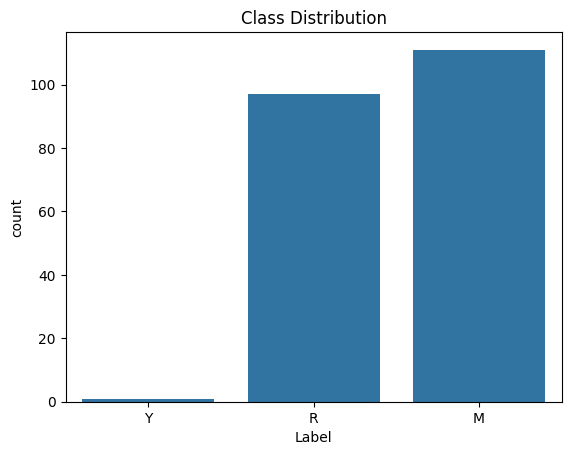

In [11]:
sns.countplot(
    x='Label',
    data=df
)

plt.title("Class Distribution")

plt.show()

In [12]:
df.describe()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_51,Feature_52,Feature_53,Feature_54,Feature_55,Feature_56,Feature_57,Feature_58,Feature_59,Label
count,209,209,209,209,209,209,209,209,209,209,...,209,209,209,209,209,209,209,209,209,209
unique,178,183,191,182,194,197,196,202,206,208,...,145,135,135,130,123,122,125,120,110,3
top,0.0201,0.0394,0.0476,0.0108,0.063,0.1267,0.0771,0.0664,0.0598,0.2354,...,0.0091,0.0129,0.0079,0.0075,0.0054,0.0037,0.0036,0.007,0.0053,M
freq,5,2,2,3,2,2,3,2,2,2,...,5,5,5,5,5,7,6,6,7,111


In [16]:
# Last column label hai
# Baaki sab numeric features hain

for col in df.columns[:-1]:
    
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [17]:
df.dtypes

Feature_0     float64
Feature_1     float64
Feature_2     float64
Feature_3     float64
Feature_4     float64
               ...   
Feature_56    float64
Feature_57    float64
Feature_58    float64
Feature_59    float64
Label          object
Length: 61, dtype: object

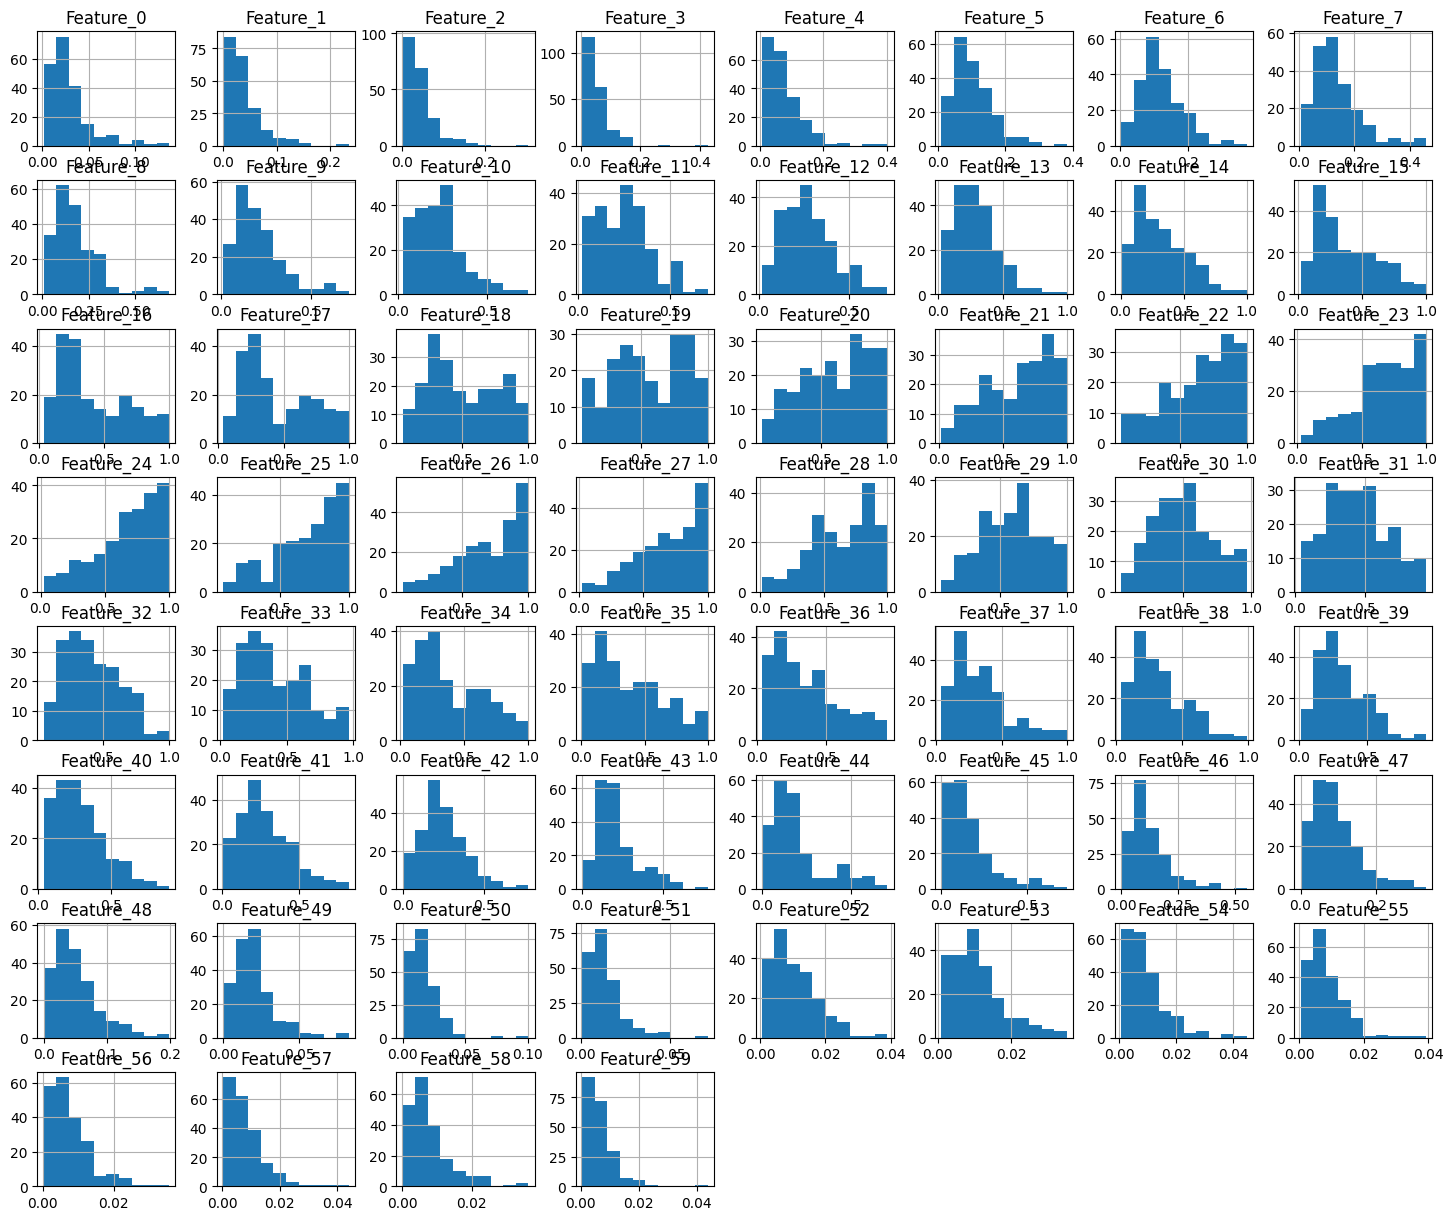

In [18]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.hist(figsize=(18,15))

plt.show()

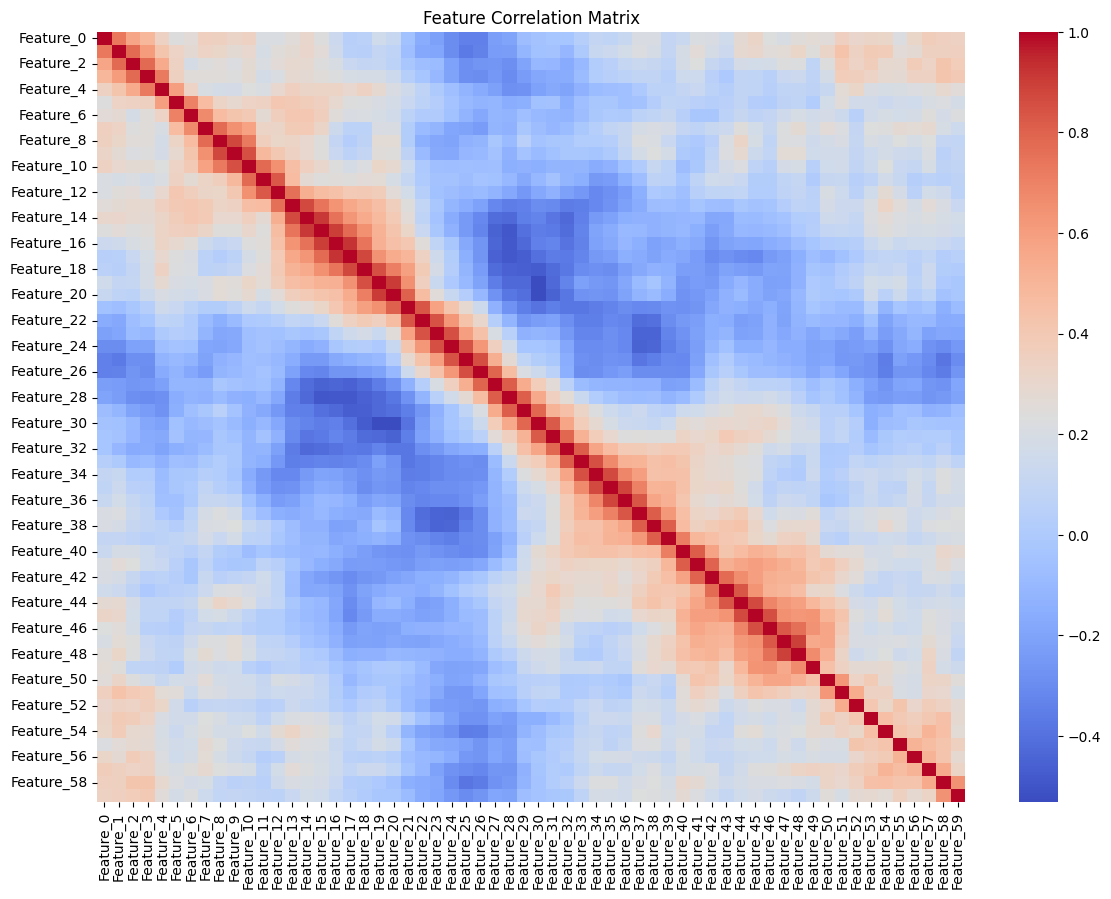

In [19]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.iloc[:,:-1].corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

In [20]:
encoder = LabelEncoder()

df['Label'] = encoder.fit_transform(df['Label'])

In [21]:
df.head()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_51,Feature_52,Feature_53,Feature_54,Feature_55,Feature_56,Feature_57,Feature_58,Feature_59,Label
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
1,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,1
2,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,1
3,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,1
4,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,1


In [22]:
X = df.drop('Label', axis=1)

y = df['Label']

In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_lr)

In [ ]:
print(classification_report(
    y_test,
    y_pred_lr
))

In [ ]:
f1_score(
    y_test,
    y_pred_lr
)

In [ ]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
svm = SVC()

svm.fit(X_train, y_train)

In [ ]:
y_pred_svm = svm.predict(X_test)

In [ ]:
accuracy_score(
    y_test,
    y_pred_svm
)

In [ ]:
print(classification_report(
    y_test,
    y_pred_svm
))

In [ ]:
f1_score(
    y_test,
    y_pred_svm
)

In [ ]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
lr_scores = cross_val_score(
    lr,
    X_scaled,
    y,
    cv=5
)

print(lr_scores.mean())

In [ ]:
svm_scores = cross_val_score(
    svm,
    X_scaled,
    y,
    cv=5
)

print(svm_scores.mean())

In [ ]:
comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'SVM'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm)
    ]
})

print(comparison)

The sonar dataset was successfully classified using Logistic Regression and Support Vector Machine models.

EDA and preprocessing helped improve model performance.

Feature scaling was important because the dataset contains numerical values with different ranges.

SVM performed better for sonar classification because it handles high-dimensional data effectively.

The models achieved strong accuracy and F1 scores, making them suitable for binary classification tasks.